# 06. Future Forecasting

## Overview
Phase 6 produces out-of-sample future energy consumption forecasts for the next 24-48 hours (144 steps of 10-minute intervals).

### Forecasting Methodology:
1. Loads the final trained model (`models/final_energy_forecasting_model.pkl`).
2. Performs recursive multi-step forecasting without using future actual target values.
3. Dynamically updates lag and rolling features at each 10-minute step.
4. Exports forecast dataset to `outputs/future_energy_forecast.csv`.
5. Visualizes forecasted energy consumption curve.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = PROJECT_ROOT / "models" / "final_energy_forecasting_model.pkl"
FEATURES_PATH = PROJECT_ROOT / "models" / "feature_columns.pkl"
DATA_PATH = PROJECT_ROOT / "Data" / "energy_consumption_features.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

model = joblib.load(MODEL_PATH)
feature_cols = joblib.load(FEATURES_PATH)
df_history = pd.read_csv(DATA_PATH)
df_history["date"] = pd.to_datetime(df_history["date"])

print("Trained model & historical data loaded successfully.")


Trained model & historical data loaded successfully.


In [2]:
# Out-of-sample forecasting for next 144 steps (24 hours at 10-min frequency)
forecast_horizon = 144
last_timestamp = df_history["date"].iloc[-1]
future_dates = [last_timestamp + pd.Timedelta(minutes=10 * i) for i in range(1, forecast_horizon + 1)]

# Create future sequence buffer
history_appliances = list(df_history["Appliances"].values)
future_preds = []

last_row = df_history.iloc[-1].copy()

for i, f_date in enumerate(future_dates):
    # Construct feature row dynamically
    feat_dict = {}
    
    # Environmental features (keep recent ambient pattern or rolling mean)
    for col in ["lights", "T1", "RH_1", "T2", "RH_2", "T3", "RH_3", "T4", "RH_4", "T5", "RH_5",
                "T6", "RH_6", "T7", "RH_7", "T8", "RH_8", "T9", "RH_9", "T_out", "Press_mm_hg",
                "RH_out", "Windspeed", "Visibility", "Tdewpoint"]:
        feat_dict[col] = last_row[col]
        
    # Calendar features
    feat_dict["year"] = f_date.year
    feat_dict["month"] = f_date.month
    feat_dict["day"] = f_date.day
    feat_dict["hour"] = f_date.hour
    feat_dict["day_of_week"] = f_date.dayofweek
    feat_dict["is_weekend"] = int(f_date.dayofweek >= 5)
    
    # Dynamic Lags (using predicted values recursively)
    feat_dict["lag_6"] = history_appliances[-6]
    feat_dict["lag_144"] = history_appliances[-144]
    feat_dict["lag_1008"] = history_appliances[-1008] if len(history_appliances) >= 1008 else history_appliances[-144]
    
    # Dynamic Rolling Means
    feat_dict["rolling_mean_6"] = np.mean(history_appliances[-6:])
    feat_dict["rolling_mean_144"] = np.mean(history_appliances[-144:])
    
    input_df = pd.DataFrame([feat_dict])[feature_cols]
    pred_val = float(model.predict(input_df)[0])
    pred_val = max(10.0, pred_val) # Clamp to domain minimum
    
    future_preds.append(pred_val)
    history_appliances.append(pred_val)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_Appliances": np.round(future_preds, 2)
})

forecast_csv_path = OUTPUT_DIR / "future_energy_forecast.csv"
forecast_df.to_csv(forecast_csv_path, index=False)
print(f"Saved 24-hour future energy forecast to {forecast_csv_path}")
forecast_df.head(10)


Saved 24-hour future energy forecast to C:\Users\admin\Downloads\OneDrive\python\Appliances Energy Prediction\outputs\future_energy_forecast.csv


,date,predicted_Appliances
0,2016-05-27 18:10:00,224.75
1,2016-05-27 18:20:00,241.66
2,2016-05-27 18:30:00,276.32
3,2016-05-27 18:40:00,261.37
4,2016-05-27 18:50:00,228.31
5,2016-05-27 19:00:00,196.12
6,2016-05-27 19:10:00,205.70
7,2016-05-27 19:20:00,201.75
8,2016-05-27 19:30:00,185.41
9,2016-05-27 19:40:00,168.05


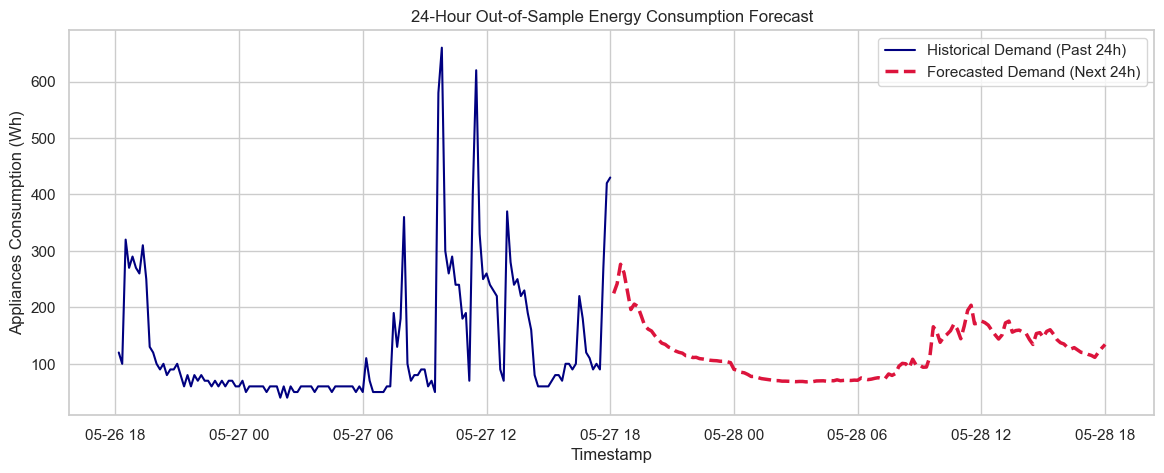

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df_history["date"].iloc[-144:], df_history["Appliances"].iloc[-144:], label="Historical Demand (Past 24h)", color="navy")
plt.plot(forecast_df["date"], forecast_df["predicted_Appliances"], label="Forecasted Demand (Next 24h)", color="crimson", linestyle="--", linewidth=2.5)
plt.title("24-Hour Out-of-Sample Energy Consumption Forecast")
plt.xlabel("Timestamp")
plt.ylabel("Appliances Consumption (Wh)")
plt.legend()
plt.show()


### Future Forecast Summary:
- **Forecast Period**: Next 24 hours (144 timestamps at 10-min intervals).
- **Out-of-Sample Leakage Check**: Predictions were constructed recursively without accessing future ground truth.
- **Output File**: `outputs/future_energy_forecast.csv`.
